In [ ]:
import pandas as pd
df = pd.read_csv("/content/Mall_Customers.csv")

In [ ]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
# Step 1 - Import the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load the Dataset
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.shape

(200, 5)

In [ ]:
(df.isnull().sum())

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
X = df[["Annual Income (k$)"	,"Spending Score (1-100)"]]

In [ ]:
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)

In [ ]:
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [ ]:
X_scaled_df

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980
...,...,...
195,2.268791,1.118061
196,2.497807,-0.861839
197,2.497807,0.923953
198,2.917671,-1.250054


In [ ]:
print('Mean of scaled data:')
print(X_scaled_df.mean())
print('\nStandard deviation of scaled data:')
print(X_scaled_df.std())

Mean of scaled data:
Annual Income (k$)       -2.131628e-16
Spending Score (1-100)   -1.465494e-16
dtype: float64

Standard deviation of scaled data:
Annual Income (k$)        1.002509
Spending Score (1-100)    1.002509
dtype: float64


Calculating WCSS for each K
K = 1: WCSS = 400.00
K = 2: WCSS = 270.16
K = 3: WCSS = 157.70
K = 4: WCSS = 109.23
K = 5: WCSS = 65.57
K = 6: WCSS = 57.38
K = 7: WCSS = 47.34
K = 8: WCSS = 44.11
K = 9: WCSS = 41.79
K = 10: WCSS = 32.16


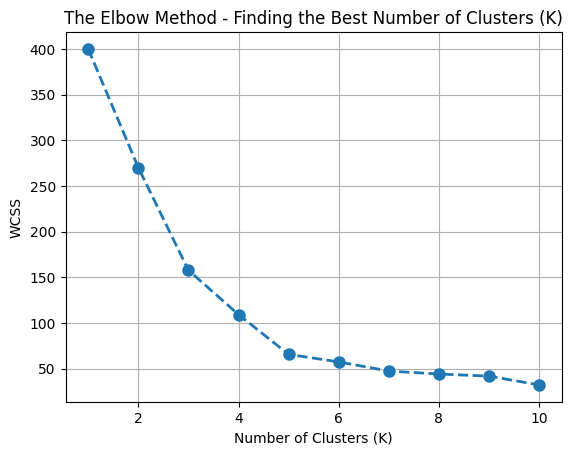

In [ ]:
# Step1 (Create an empty list to store the WCSS values)
wcss = [] # List (Create an empty list to store the WCSS values)

# Step 2 - Try and implement K from 1 to 10
print("Calculating WCSS for each K")

for k in range(1,11):
  # Create the K-Means Model with K clusters
  kmeans = KMeans(n_clusters=k , random_state = 7)

# Step 3 - Train the model
  kmeans.fit(X_scaled)

  # Step 4 -Get the WCSS values (inertia_ is the WCSS)
  wcss.append(kmeans.inertia_)

  # Print the values
  print(f"K = {k}: WCSS = {kmeans.inertia_:.2f}")

# Step 5 Elbow Graph

plt.plot(range(1,11), wcss , marker = "o" , linestyle = "--", linewidth = 2 , markersize = 8)
plt.title("The Elbow Method - Finding the Best Number of Clusters (K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [ ]:
# Creating the Kmeans model with K=5

kmeans = KMeans(n_clusters=5 , random_state = 7)

# Training the model with scaled data
kmeans.fit(X_scaled)

# Get the cluster labels for each customer
labels = kmeans.labels_

# Add the cluster labels to the DataFrame
df["Cluster"] = labels

df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,0
2,3,Female,20,16,6,4
3,4,Female,23,16,77,0
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,3
196,197,Female,45,126,28,1
197,198,Male,32,126,74,3
198,199,Male,32,137,18,1


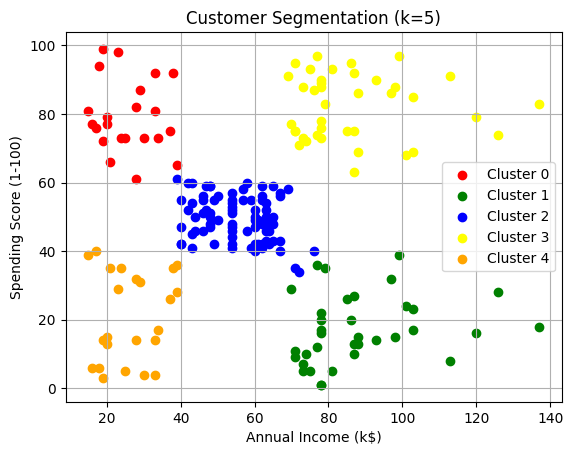

In [ ]:
colors = ["red" , "green" , "blue" , "yellow" , "orange"]

for i in range(5):
  cluster_data = df[df["Cluster"] == i]
  plt.scatter(cluster_data["Annual Income (k$)"] , cluster_data["Spending Score (1-100)"] , c = colors[i] , label = f"Cluster {i}")

plt.title("Customer Segmentation (k=5)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,0
2,3,Female,20,16,6,4
3,4,Female,23,16,77,0
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,3
196,197,Female,45,126,28,1
197,198,Male,32,126,74,3
198,199,Male,32,137,18,1


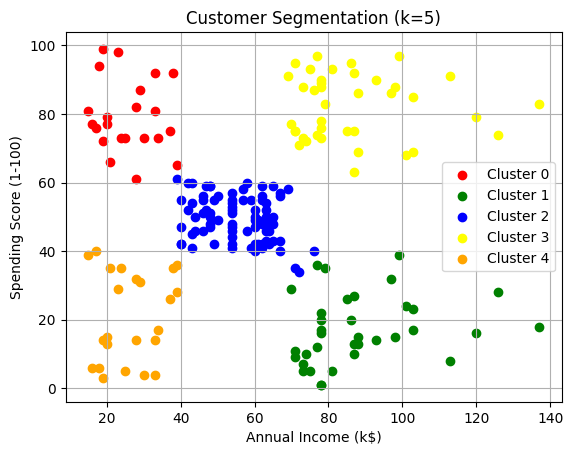

In [ ]:
colors = ["red" , "green" , "blue" , "yellow" , "orange"]

for i in range(5):
  cluster_data = df[df["Cluster"] == i]
  plt.scatter(cluster_data["Annual Income (k$)"] , cluster_data["Spending Score (1-100)"] , c = colors[i] , label = f"Cluster {i}")

plt.title("Customer Segmentation (k=5)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
cluster_summary = df.groupby("Cluster").agg({
    "Age" : "mean",
    "Annual Income (k$)" : "mean",
    "Spending Score (1-100)" : "mean",
    "CustomerID" : "count"
}).rename(columns={"CustomerID" : "Number of Customers"})

print("Cluster Summary")
cluster_summary

Cluster Summary


,Age,Annual Income (k$),Spending Score (1-100),Number of Customers
Cluster,,,,
0,25.272727,25.727273,79.363636,22
1,41.114286,88.200000,17.114286,35
2,42.716049,55.296296,49.518519,81
3,32.692308,86.538462,82.128205,39
4,45.217391,26.304348,20.913043,23
